# 1단계: EDA + 가설 검증

**가설**: 미세먼지 계절관리제 시행(2019년 12월) 이후 겨울철(12~3월) PM10/PM2.5 농도가 시행 전 겨울철 대비 유의미하게 감소했다.

**검증 기준**
1. 월평균 추이 lineplot에 시행 시점이 표시되는가
2. 시행 전/후 겨울철 boxplot 비교가 나오는가 (같은 계절끼리 비교 - 계절 교란 보완)
3. 통계 검정(t-test / Mann-Whitney U) p-value가 산출되는가

**분석 대상 필터**
- 도시대기 측정소만 사용 (도로변대기는 계통적 고농도 + 지역 편중으로 제외)
- network 미상(폐쇄 추정) 측정소 제외 (전체의 약 4.2%)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 그래프 한글 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = "../data/processed/airkorea_daily.parquet"

daily = pd.read_parquet(DATA_PATH)
daily["date"] = pd.to_datetime(daily["date"])

print("전체:", daily.shape)
print(daily["network"].value_counts(dropna=False))

전체: (1779743, 9)
network
도시대기     1401587
도로변대기     157826
교외대기       81708
NaN        75187
항만         39836
국가배경       23599
Name: count, dtype: int64


In [9]:
# 도시대기만 필터링 (network NaN도 여기서 함께 제외됨)
urban = daily[daily["network"] == "도시대기"].copy()

print("도시대기:", urban.shape)
print("측정소 수:", urban["station_code"].nunique())
print("기간:", urban["date"].min(), "~", urban["date"].max())

도시대기: (1401587, 9)
측정소 수: 530
기간: 2015-01-01 00:00:00 ~ 2024-12-31 00:00:00


## 1. 월평균 추이 (2015~2024)

전국 도시대기 측정소의 월평균 농도 추이. 빨간 세로선 = 계절관리제 최초 시행(2019-12).
겨울마다 농도가 치솟는 계절성이 보이므로, 전/후 비교는 반드시 같은 계절(겨울)끼리 해야 한다.

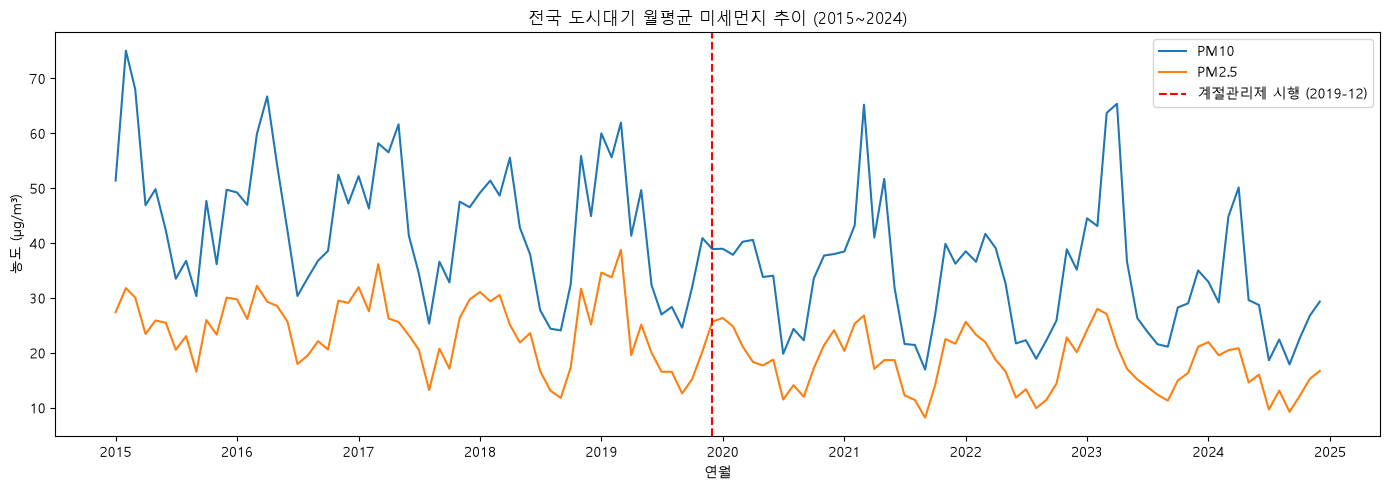

In [10]:
monthly = (
    urban.set_index("date")[["pm10", "pm25"]]
    .resample("MS")
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=monthly, x="date", y="pm10", label="PM10", ax=ax)
sns.lineplot(data=monthly, x="date", y="pm25", label="PM2.5", ax=ax)
ax.axvline(pd.Timestamp("2019-12-01"), color="red", linestyle="--", label="계절관리제 시행 (2019-12)")
ax.set_title("전국 도시대기 월평균 미세먼지 추이 (2015~2024)")
ax.set_xlabel("연월")
ax.set_ylabel("농도 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. 겨울철 정의 및 전/후 그룹 구성

- 겨울 = 12월(해당 연도) + 이듬해 1~3월. 예: "2019 겨울" = 2019-12 ~ 2020-03 (첫 계절관리제 기간)
- 시행 전 = 2015~2018 겨울 (4개), 시행 후 = 2019~2023 겨울 (5개)
- 2024 겨울은 12월 한 달만 존재(데이터가 2024-12-31 종료)하는 반쪽 겨울이라 제외
  (1~3월 고농도 구간이 빠진 채 포함하면 시행 후 평균이 왜곡됨)

**통계 검정의 분석 단위**: 측정소x일 원자료를 그대로 쓰면 표본 수십만 개가 서로 상관되어
p-value가 무의미해지므로(pseudo-replication), 일별 전국 평균(1일 1값)으로 축약해 비교한다.
시계열 자기상관이 남는 한계는 보고서에 명시.

In [11]:
winter = urban[urban["date"].dt.month.isin([12, 1, 2, 3])].copy()

# 겨울 라벨: 12월은 그 해, 1~3월은 전년도 겨울로 귀속
winter["winter_year"] = winter["date"].dt.year.where(
    winter["date"].dt.month == 12, winter["date"].dt.year - 1
)

# 2014 겨울(2015년 1~3월, 12월 없음)과 2024 겨울(12월만 존재) 제외 - 완전한 겨울만 사용
winter = winter[winter["winter_year"].between(2015, 2023)]

winter["period"] = winter["winter_year"].apply(
    lambda y: "시행 전 (2015~2018)" if y <= 2018 else "시행 후 (2019~2023)"
)

# 일별 전국 평균으로 축약 (통계 검정용 분석 단위)
winter_daily = (
    winter.groupby(["date", "period"])[["pm10", "pm25"]].mean().reset_index()
)

print(winter_daily.groupby("period").size())

period
시행 전 (2015~2018)    485
시행 후 (2019~2023)    607
dtype: int64


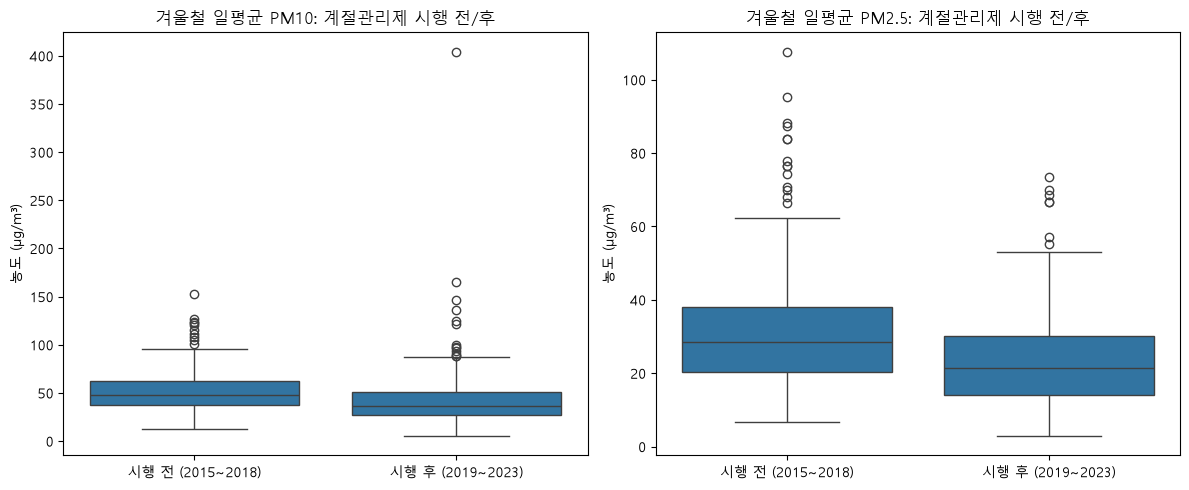

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ["pm10", "pm25"], ["PM10", "PM2.5"]):
    sns.boxplot(data=winter_daily, x="period", y=col, ax=ax)
    ax.set_title(f"겨울철 일평균 {title}: 계절관리제 시행 전/후")
    ax.set_xlabel("")
    ax.set_ylabel("농도 (µg/m³)")
plt.tight_layout()
plt.show()

In [13]:
# 시행 후 구간의 고농도 상위 날짜 확인
top_days = winter_daily.sort_values("pm10", ascending=False).head(15)
print(top_days[["date", "period", "pm10", "pm25"]])

           date            period        pm10        pm25
725  2021-03-29  시행 후 (2019~2023)  404.392794   69.996094
726  2021-03-30  시행 후 (2019~2023)  165.641870   29.740672
458  2019-03-05  시행 전 (2015~2018)  152.795511  107.679202
1089 2024-03-29  시행 후 (2019~2023)  146.843538   32.809603
861  2022-12-13  시행 후 (2019~2023)  135.725995   32.968427
408  2019-01-14  시행 전 (2015~2018)  127.206588   95.325987
886  2023-01-07  시행 후 (2019~2023)  125.022419   73.384508
454  2019-03-01  시행 전 (2015~2018)  123.734144   87.288716
459  2019-03-06  시행 전 (2015~2018)  122.299285   88.316470
962  2023-03-24  시행 후 (2019~2023)  122.043723   24.817238
457  2019-03-04  시행 전 (2015~2018)  120.174524   83.746145
409  2019-01-15  시행 전 (2015~2018)  114.984326   76.551702
272  2017-12-30  시행 전 (2015~2018)  111.038635   83.862445
455  2019-03-02  시행 전 (2015~2018)  108.140185   74.178019
171  2017-01-19  시행 전 (2015~2018)  104.986847   77.718069


## 3. 통계 검정

- 분포 정규성을 먼저 확인한다. 대기오염 농도는 보통 오른쪽으로 치우친(right-skewed) 분포라
  정규성이 깨질 가능성이 높다.
- 정규성과 무관하게 쓸 수 있는 Mann-Whitney U를 기본으로 하되, 참고용으로 Welch t-test도 함께 출력한다.
  (표본이 수백 개 이상이라 중심극한정리로 t-test도 크게 어긋나지 않지만, 두 결과가 일치하는지 확인)

In [14]:
for col in ["pm10", "pm25"]:
    before = winter_daily.loc[winter_daily["period"].str.startswith("시행 전"), col].dropna()
    after = winter_daily.loc[winter_daily["period"].str.startswith("시행 후"), col].dropna()

    t_stat, t_p = stats.ttest_ind(before, after, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(before, after, alternative="two-sided")

    print(f"=== {col.upper()} ===")
    print(f"시행 전 평균: {before.mean():.1f} µg/m³ (n={len(before)})")
    print(f"시행 후 평균: {after.mean():.1f} µg/m³ (n={len(after)})")
    print(f"변화율: {(after.mean() - before.mean()) / before.mean() * 100:+.1f}%")
    print(f"Welch t-test:   p = {t_p:.2e}")
    print(f"Mann-Whitney U: p = {u_p:.2e}")
    print()

=== PM10 ===
시행 전 평균: 51.8 µg/m³ (n=485)
시행 후 평균: 41.1 µg/m³ (n=607)
변화율: -20.6%
Welch t-test:   p = 2.40e-15
Mann-Whitney U: p = 3.35e-25

=== PM25 ===
시행 전 평균: 31.1 µg/m³ (n=485)
시행 후 평균: 23.4 µg/m³ (n=607)
변화율: -24.5%
Welch t-test:   p = 1.28e-19
Mann-Whitney U: p = 3.02e-20



## 해석 시 주의 (보고서에 반영할 것)

- p-value가 유의하더라도 이것이 곧 "계절관리제의 효과"를 의미하지는 않는다.
  같은 기간에 코로나19(2020~2022, 경제활동 감소), 중국발 오염 변화 등 외부 요인이 겹쳐 있다.
  -> 관측된 감소 = 정책 + 외부 요인의 합. 인과가 아닌 연관으로 서술할 것.
- 2015~2018 PM2.5는 측정망 확충 이전이라 결측이 많음(약 40%). 시행 전 평균의 대표성 한계를 명시.
- 일별 전국 평균 간에도 시계열 자기상관이 존재하므로 p-value는 실제보다 낙관적일 수 있음.

**다음 단계(2단계)**: 시/도별 개선율 계산 -> SAW 매트릭스의 입력 데이터 생성